# PCA Analysis of PM2.5 Input Feature Space

Explore the structure of the input feature space used in GP modeling:
1. Which features drive the most variation?
2. Is there obvious linear separation (by state, season, PM2.5 level)?
3. What is the effective dimensionality of the input space?

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Load data (same pipeline as SVGP script)
pm_all = pd.read_csv('../../data/pm25_data_complete_2003_2021_smogI_031026.csv', low_memory=False)
pm_fixed = pd.read_csv('../pm25_locs_with_states.csv')

pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')

time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']

pm_subset = pm_all[['ll_id', 'date', 'pm25'] + time_varying_features].copy()
static_df = pm_fixed[['ll_id', 'state'] + static_features].copy()
df = pm_subset.merge(static_df, on='ll_id', how='left')
df['day_of_year'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

feature_cols = time_varying_features + static_features + ['day_of_year']
df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()

print(f'Observations: {len(df_clean):,}')
print(f'Sites: {df_clean["ll_id"].nunique()}')
print(f'States: {df_clean["state"].nunique()}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Observations: 1,984,573
Sites: 968
States: 15
Features (17): ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing', 'day_of_year']


In [2]:
# Standardize features and run PCA
X = df_clean[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance by component:')
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1:2d}: {ev:.4f}  (cumulative: {cum:.4f})')

Explained variance by component:
  PC 1: 0.2068  (cumulative: 0.2068)
  PC 2: 0.1521  (cumulative: 0.3589)
  PC 3: 0.0984  (cumulative: 0.4573)
  PC 4: 0.0968  (cumulative: 0.5541)
  PC 5: 0.0705  (cumulative: 0.6246)
  PC 6: 0.0649  (cumulative: 0.6895)
  PC 7: 0.0610  (cumulative: 0.7504)
  PC 8: 0.0510  (cumulative: 0.8014)
  PC 9: 0.0399  (cumulative: 0.8413)
  PC10: 0.0370  (cumulative: 0.8783)
  PC11: 0.0315  (cumulative: 0.9098)
  PC12: 0.0268  (cumulative: 0.9367)
  PC13: 0.0235  (cumulative: 0.9602)
  PC14: 0.0198  (cumulative: 0.9800)
  PC15: 0.0111  (cumulative: 0.9911)
  PC16: 0.0085  (cumulative: 0.9995)
  PC17: 0.0005  (cumulative: 1.0000)


## 1. Effective Dimensionality

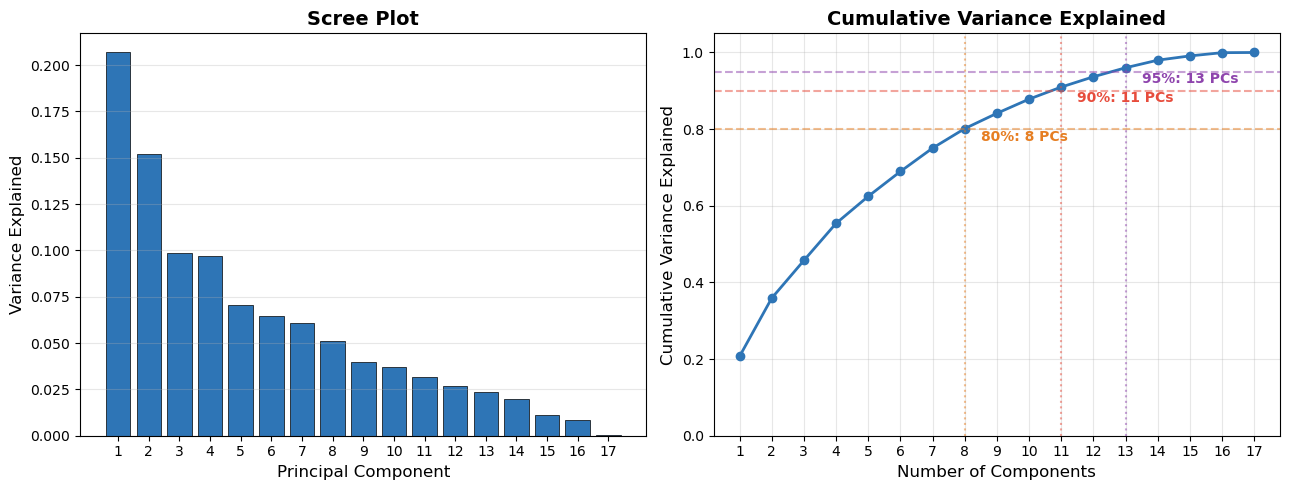

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained, color='#2E75B6', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, len(explained)+1))
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='#2E75B6', linewidth=2, markersize=6)
for threshold, color, label in [(0.80, '#E67E22', '80%'), (0.90, '#e74c3c', '90%'), (0.95, '#8E44AD', '95%')]:
    n_components = np.argmax(cumulative >= threshold) + 1
    axes[1].axhline(y=threshold, color=color, linestyle='--', alpha=0.5)
    axes[1].axvline(x=n_components, color=color, linestyle=':', alpha=0.5)
    axes[1].annotate(f'{label}: {n_components} PCs', xy=(n_components, threshold),
                     xytext=(n_components+0.5, threshold-0.03), fontsize=10, color=color, fontweight='bold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scree_and_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature Loadings — What Drives Variation?

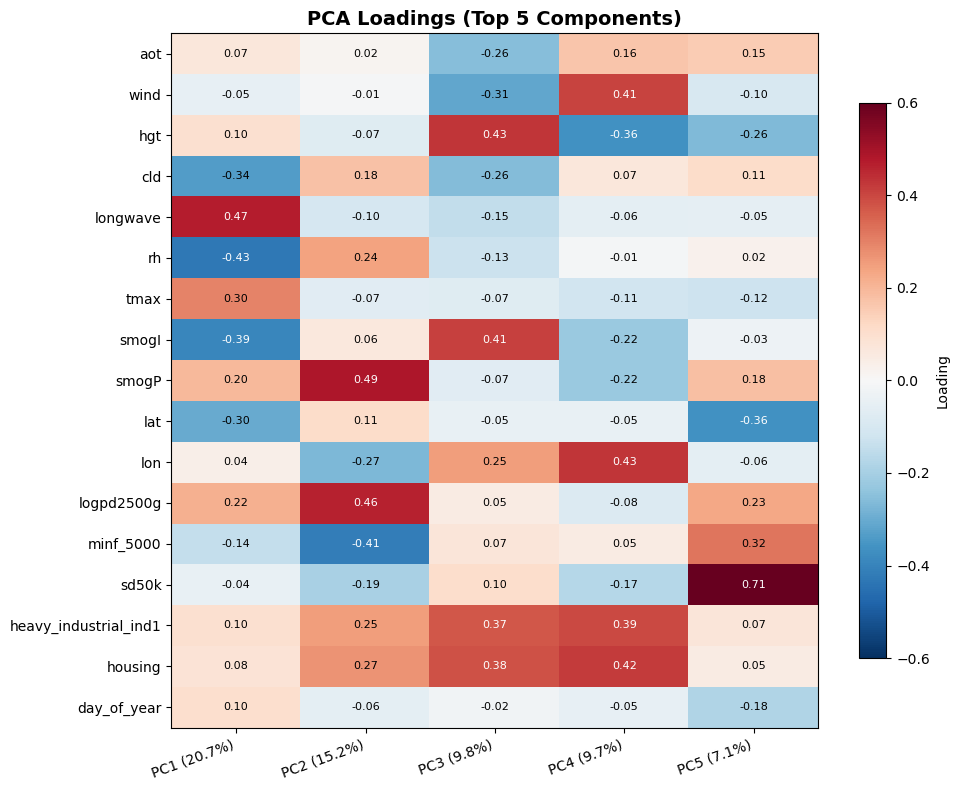

In [4]:
# Top 5 components loading heatmap
n_show = min(5, len(feature_cols))
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=feature_cols,
    columns=[f'PC{i+1} ({explained[i]:.1%})' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-0.6, vmax=0.6)
ax.set_xticks(range(n_show))
ax.set_xticklabels(loadings.columns, fontsize=10, rotation=20, ha='right')
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=10)
ax.set_title('PCA Loadings (Top 5 Components)', fontsize=14, fontweight='bold')

# Annotate cells
for i in range(len(feature_cols)):
    for j in range(n_show):
        val = loadings.values[i, j]
        color = 'white' if abs(val) > 0.35 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Loading')
plt.tight_layout()
plt.savefig('loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Top contributing features per component
print('Top 3 features by absolute loading per component:\n')
for i in range(n_show):
    abs_loadings = np.abs(pca.components_[i])
    top_idx = np.argsort(abs_loadings)[::-1][:3]
    top_feats = [(feature_cols[j], pca.components_[i][j]) for j in top_idx]
    print(f'PC{i+1} ({explained[i]:.1%}): ', end='')
    print(', '.join([f'{name} ({val:+.3f})' for name, val in top_feats]))

Top 3 features by absolute loading per component:

PC1 (20.7%): longwave (+0.469), rh (-0.428), smogI (-0.392)
PC2 (15.2%): smogP (+0.486), logpd2500g (+0.463), minf_5000 (-0.415)
PC3 (9.8%): hgt (+0.427), smogI (+0.412), housing (+0.381)
PC4 (9.7%): lon (+0.427), housing (+0.421), wind (+0.407)
PC5 (7.1%): sd50k (+0.709), lat (-0.362), minf_5000 (+0.323)


## 3. Linear Separation — PC1 vs PC2 Colored by State, Season, PM2.5

In [6]:
# Subsample for plotting (full dataset is too dense)
rng = np.random.RandomState(42)
n_plot = 50000
idx = rng.choice(len(df_clean), size=n_plot, replace=False)

pc1 = X_pca[idx, 0]
pc2 = X_pca[idx, 1]
states = df_clean['state'].values[idx]
months = df_clean['month'].values[idx]
pm25 = df_clean['pm25'].values[idx]
log_pm25 = np.log(pm25 + 1)

# Define seasons
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall'}
seasons = np.array([season_map[m] for m in months])

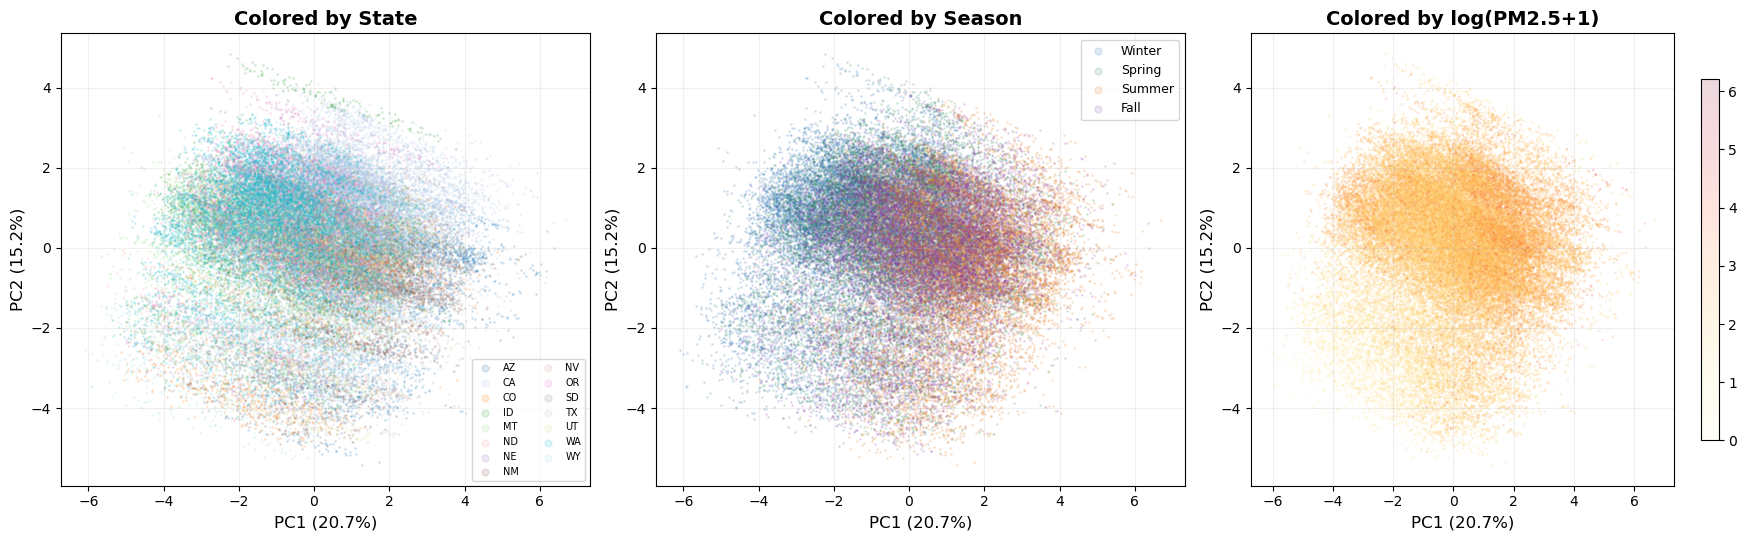

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# By state
unique_states = sorted(df_clean['state'].unique())
cmap_state = plt.cm.get_cmap('tab20', len(unique_states))
for i, st in enumerate(unique_states):
    mask = states == st
    axes[0].scatter(pc1[mask], pc2[mask], s=1, alpha=0.15, color=cmap_state(i), label=st)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
axes[0].set_title('Colored by State', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=5, ncol=2, loc='best')
axes[0].grid(alpha=0.2)

# By season
season_colors = {'Winter': '#2E75B6', 'Spring': '#2D8B57', 'Summer': '#E67E22', 'Fall': '#8E44AD'}
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    mask = seasons == season
    axes[1].scatter(pc1[mask], pc2[mask], s=1, alpha=0.15, color=season_colors[season], label=season)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
axes[1].set_title('Colored by Season', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=5)
axes[1].grid(alpha=0.2)

# By PM2.5
sc = axes[2].scatter(pc1, pc2, c=log_pm25, s=1, alpha=0.15, cmap='YlOrRd')
axes[2].set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
axes[2].set_ylabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
axes[2].set_title('Colored by log(PM2.5+1)', fontsize=14, fontweight='bold')
plt.colorbar(sc, ax=axes[2], shrink=0.8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('pc1_pc2_separation.png', dpi=150, bbox_inches='tight')
plt.show()

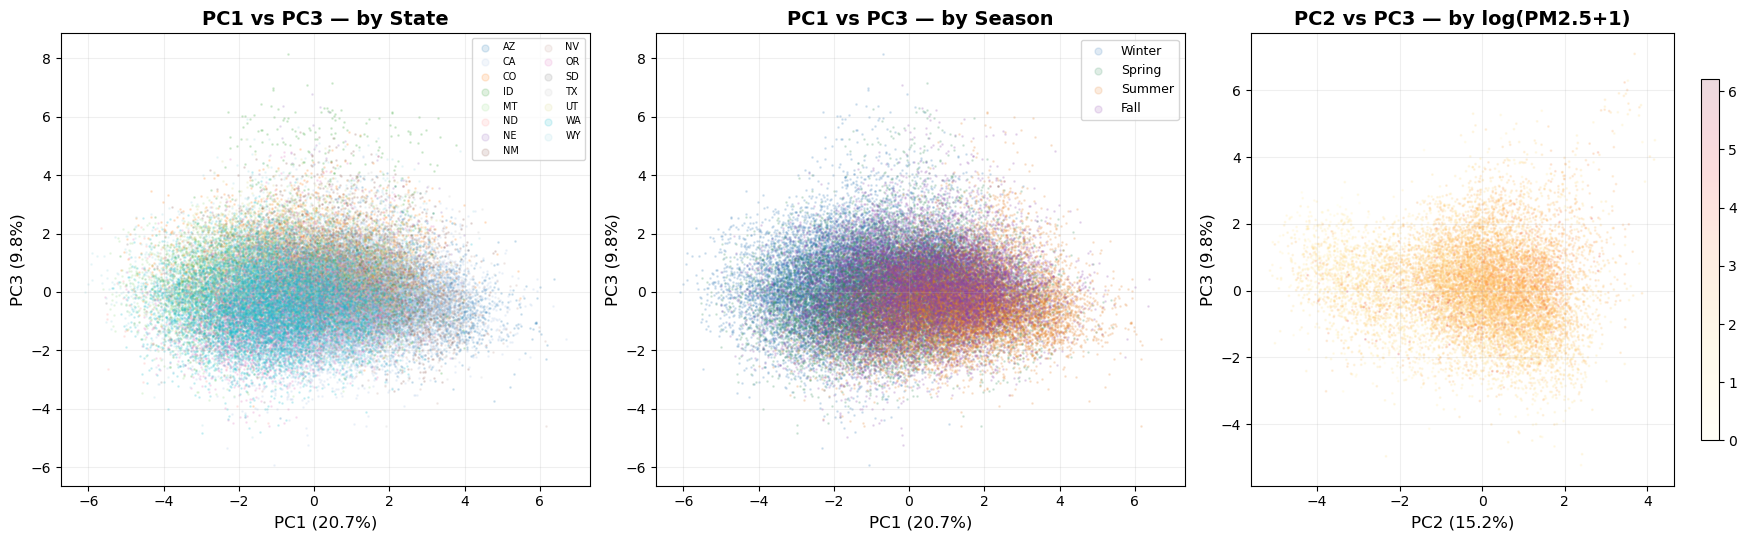

In [8]:
# PC1 vs PC3, PC2 vs PC3 — check if structure extends beyond first 2 components
pc3 = X_pca[idx, 2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# PC1 vs PC3 by state
for i, st in enumerate(unique_states):
    mask = states == st
    axes[0].scatter(pc1[mask], pc3[mask], s=1, alpha=0.15, color=cmap_state(i), label=st)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC3 ({explained[2]:.1%})', fontsize=12)
axes[0].set_title('PC1 vs PC3 — by State', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=5, ncol=2, loc='best')
axes[0].grid(alpha=0.2)

# PC1 vs PC3 by season
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    mask = seasons == season
    axes[1].scatter(pc1[mask], pc3[mask], s=1, alpha=0.15, color=season_colors[season], label=season)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC3 ({explained[2]:.1%})', fontsize=12)
axes[1].set_title('PC1 vs PC3 — by Season', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, markerscale=5)
axes[1].grid(alpha=0.2)

# PC2 vs PC3 by PM2.5
sc = axes[2].scatter(pc2[mask], pc3[mask], c=log_pm25[mask], s=1, alpha=0.15, cmap='YlOrRd')
axes[2].set_xlabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
axes[2].set_ylabel(f'PC3 ({explained[2]:.1%})', fontsize=12)
axes[2].set_title('PC2 vs PC3 — by log(PM2.5+1)', fontsize=14, fontweight='bold')
plt.colorbar(sc, ax=axes[2], shrink=0.8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('pc_higher_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Biplot — Feature Vectors in PC Space

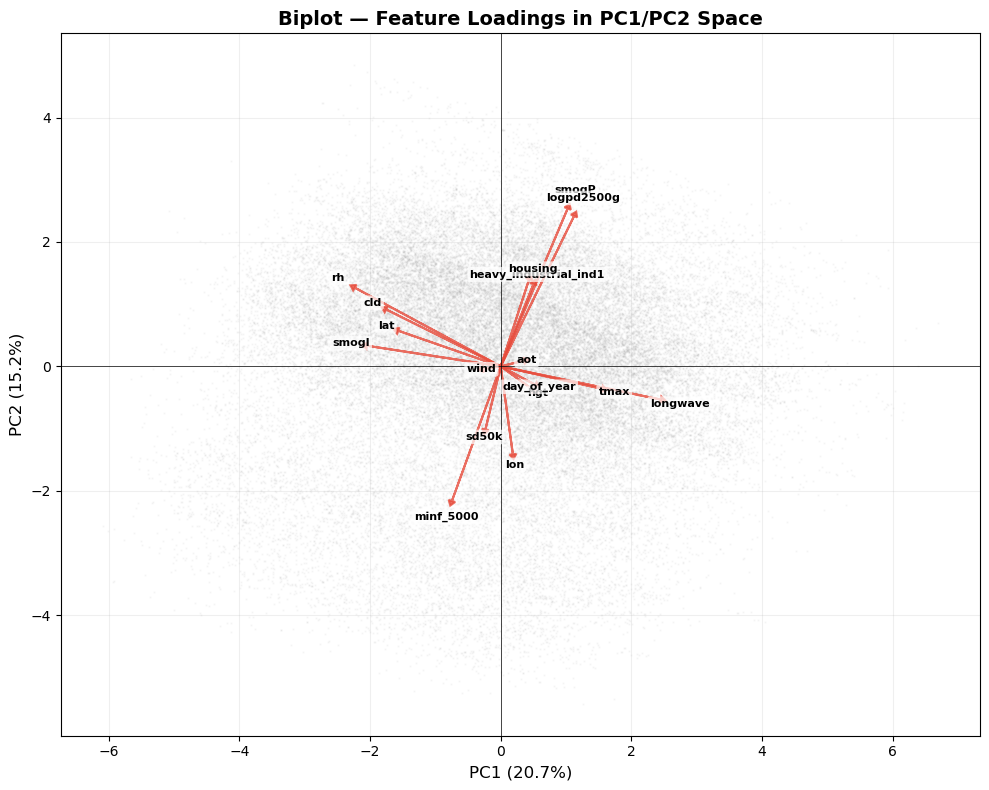

In [9]:
# Biplot: observations + feature loading vectors
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter subsample
ax.scatter(pc1, pc2, s=0.5, alpha=0.05, color='gray')

# Feature vectors (scaled for visibility)
loadings_pc1 = pca.components_[0]
loadings_pc2 = pca.components_[1]
scale = np.max(np.abs(X_pca[:, :2])) * 0.7

for i, feat in enumerate(feature_cols):
    ax.arrow(0, 0, loadings_pc1[i]*scale, loadings_pc2[i]*scale,
             head_width=scale*0.02, head_length=scale*0.015,
             fc='#e74c3c', ec='#e74c3c', alpha=0.8, linewidth=1.5)
    ax.text(loadings_pc1[i]*scale*1.12, loadings_pc2[i]*scale*1.12,
            feat, fontsize=8, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
ax.set_title('Biplot — Feature Loadings in PC1/PC2 Space', fontsize=14, fontweight='bold')
ax.grid(alpha=0.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('biplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-State PCA Centroids

How separated are states in the PC space?

state  n_obs  PC1_mean  PC2_mean  PC3_mean  PC1_std  PC2_std
   AZ 104556  1.859968 -1.146147  0.066197 1.662030 1.573189
   CA 603628  0.934642  0.310181 -0.277666 1.426206 1.554692
   CO  84014 -0.115493 -0.876247  1.178029 1.879262 1.634274
   ID 111003 -0.776794  0.202744  0.477949 1.775519 1.394087
   MT 118055 -1.505292 -0.393395  0.165468 1.754649 1.454837
   ND  14051 -1.516351 -1.363126 -0.260768 1.854586 1.237743
   NE   1715  1.263710  2.345466  3.336078 1.503698 0.674976
   NM  94457  0.852291 -1.263122  0.766042 1.636146 1.341879
   NV  65221  1.033357 -0.830323  0.152154 1.772581 1.567613
   OR 237045 -0.769400  0.722852 -0.355614 1.359221 1.257323
   SD   8235 -0.922781 -1.988774  0.496563 1.690308 1.641618
   TX  25691  2.118805 -0.416187  0.086009 1.262751 1.385480
   UT  93320 -0.205573 -0.261985  0.964329 1.672545 1.614179
   WA 355615 -1.073815  0.557860 -0.429936 1.460056 1.223980
   WY  67967 -1.135497 -1.463373  0.672171 1.943285 1.758485


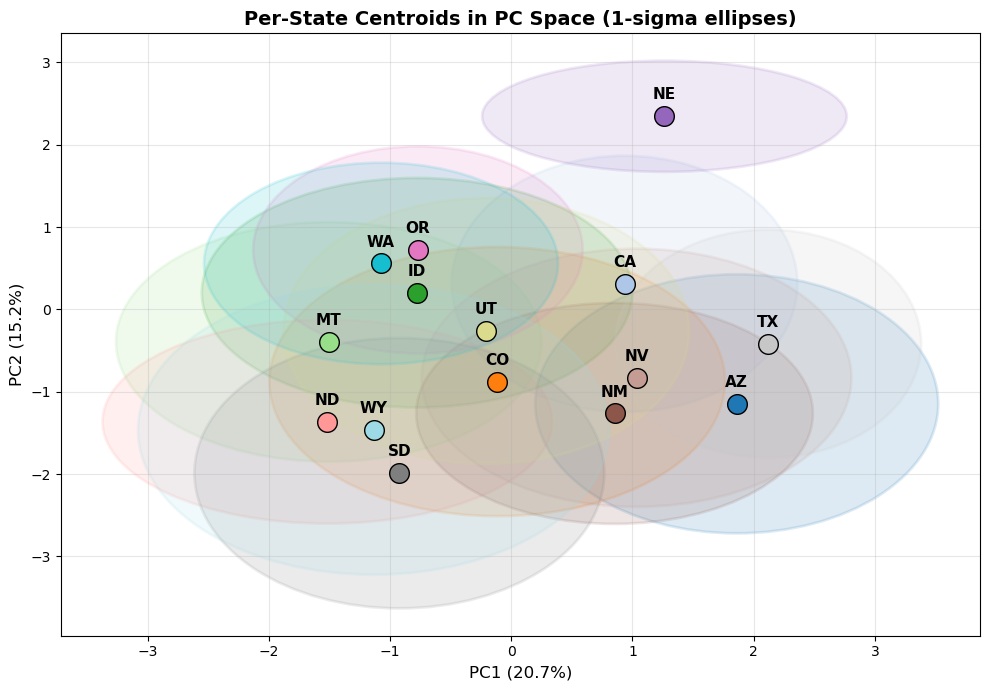

In [10]:
# Compute per-state centroids and spread in PC space
state_stats = []
all_states_arr = df_clean['state'].values
for st in unique_states:
    mask = all_states_arr == st
    pcs = X_pca[mask, :5]
    state_stats.append({
        'state': st,
        'n_obs': mask.sum(),
        'PC1_mean': pcs[:, 0].mean(),
        'PC2_mean': pcs[:, 1].mean(),
        'PC3_mean': pcs[:, 2].mean(),
        'PC1_std': pcs[:, 0].std(),
        'PC2_std': pcs[:, 1].std(),
    })

state_df = pd.DataFrame(state_stats)
print(state_df.to_string(index=False))

# Plot centroids with error ellipses
fig, ax = plt.subplots(figsize=(10, 7))
for i, row in state_df.iterrows():
    color = cmap_state(i)
    ax.scatter(row['PC1_mean'], row['PC2_mean'], s=200, color=color,
              edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(row['state'], (row['PC1_mean'], row['PC2_mean']),
               fontsize=11, fontweight='bold', ha='center', va='bottom',
               xytext=(0, 10), textcoords='offset points')
    # 1-sigma ellipse
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['PC1_mean'], row['PC2_mean']),
                      width=2*row['PC1_std'], height=2*row['PC2_std'],
                      fill=True, facecolor=color, alpha=0.15, edgecolor=color, linewidth=2)
    ax.add_patch(ellipse)

ax.set_xlabel(f'PC1 ({explained[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]:.1%})', fontsize=12)
ax.set_title('Per-State Centroids in PC Space (1-sigma ellipses)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('state_centroids.png', dpi=150, bbox_inches='tight')
plt.show()